# Medical Insurance Cost Preprocessing Pipeline
Comprehensive preprocessing pipeline covering:
1. Data Ingestion & Safe Reading
2. Structural Inspection (`check_data_type`)
3. Duplicate Handling
4. Data Type Conversion (Categorical vs Numerical)
5. Missing Values & Summary Check
6. Outlier Detection (IQR Method)
7. Visualizations (Boxplots & Distribution)

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
DATA_PATH = 'D:\\Depi R5\\Technical\\src\\DA\\Session3\\Materials\\insurance.csv'
CAT_COLS = ['sex', 'smoker', 'region']
NUM_COLS = ['age', 'bmi', 'children', 'charges']

In [10]:
import os

def read_data_file(file_path: str) -> pd.DataFrame:
    """Reads CSV safely with defensive checks."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
    return pd.read_csv(file_path)

df = read_data_file(DATA_PATH)
print(f"Dataset Loaded Successfully! Shape: {df.shape}")
df.head()

Dataset Loaded Successfully! Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [11]:
def check_data_type(df: pd.DataFrame) -> pd.DataFrame:
    """Generates a transposed data-quality summary report."""
    report = pd.DataFrame({
        "Datatype": df.dtypes.astype(str),
        "Unique_Values": df.nunique(),
        "Missing_Values": df.isnull().sum(),
        "Missing_Ratio(%)": (df.isnull().sum() / len(df)) * 100
    })
    return report.T

print("=== Initial Structural Report ===")
check_data_type(df)

=== Initial Structural Report ===


,age,sex,bmi,children,smoker,region,charges
Datatype,int64,str,float64,int64,str,str,float64
Unique_Values,47,2,548,6,2,4,1337
Missing_Values,0,0,0,0,0,0,0
Missing_Ratio(%),0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
# Check and drop duplicate records
initial_len = len(df)
duplicates_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates_count}")

if duplicates_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"Removed duplicates. Rows reduced from {initial_len} to {len(df)}")

Number of duplicate rows: 1
Removed duplicates. Rows reduced from 1338 to 1337


In [13]:
# Convert categorical features to category dtype
df[CAT_COLS] = df[CAT_COLS].astype("category")

print("=== Data Types After Conversion ===")
check_data_type(df)

=== Data Types After Conversion ===


,age,sex,bmi,children,smoker,region,charges
Datatype,int64,category,float64,int64,category,category,float64
Unique_Values,47,2,548,6,2,4,1337
Missing_Values,0,0,0,0,0,0,0
Missing_Ratio(%),0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
# Inspect outliers across continuous numerical columns
continuous_num_cols = ['age', 'bmi', 'charges']

print("=== Outlier Detection Summary (IQR Method) ===")
for col in continuous_num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    
    lower_outliers = df[df[col] < lower_fence][col]
    upper_outliers = df[df[col] > upper_fence][col]
    
    print(f"[{col}] Bounds: [{lower_fence:.2f}, {upper_fence:.2f}] | "
          f"Lower Outliers: {len(lower_outliers)} | Upper Outliers: {len(upper_outliers)}")

=== Outlier Detection Summary (IQR Method) ===
[age] Bounds: [-9.00, 87.00] | Lower Outliers: 0 | Upper Outliers: 0
[bmi] Bounds: [13.67, 47.32] | Lower Outliers: 0 | Upper Outliers: 9
[charges] Bounds: [-13120.72, 34524.78] | Lower Outliers: 0 | Upper Outliers: 139


C:\Users\Youssef Mohamed\AppData\Local\Temp\ipykernel_10804\1914009843.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], palette="Set2")
C:\Users\Youssef Mohamed\AppData\Local\Temp\ipykernel_10804\1914009843.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], palette="Set2")
C:\Users\Youssef Mohamed\AppData\Local\Temp\ipykernel_10804\1914009843.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], palette="Set2")


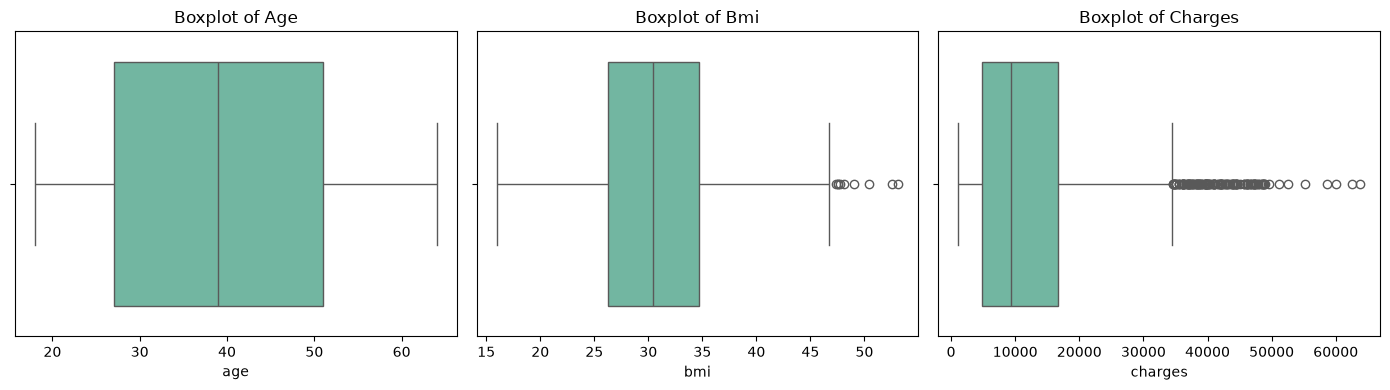

In [15]:
# Visualize numerical features distribution and outliers
plt.figure(figsize=(14, 4))
for i, col in enumerate(continuous_num_cols):
    plt.subplot(1, len(continuous_num_cols), i + 1)
    sns.boxplot(x=df[col], palette="Set2")
    plt.title(f"Boxplot of {col.capitalize()}")

plt.tight_layout()
plt.show()

C:\Users\Youssef Mohamed\AppData\Local\Temp\ipykernel_10804\1711315507.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="pastel")
C:\Users\Youssef Mohamed\AppData\Local\Temp\ipykernel_10804\1711315507.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="pastel")
C:\Users\Youssef Mohamed\AppData\Local\Temp\ipykernel_10804\1711315507.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="pastel")


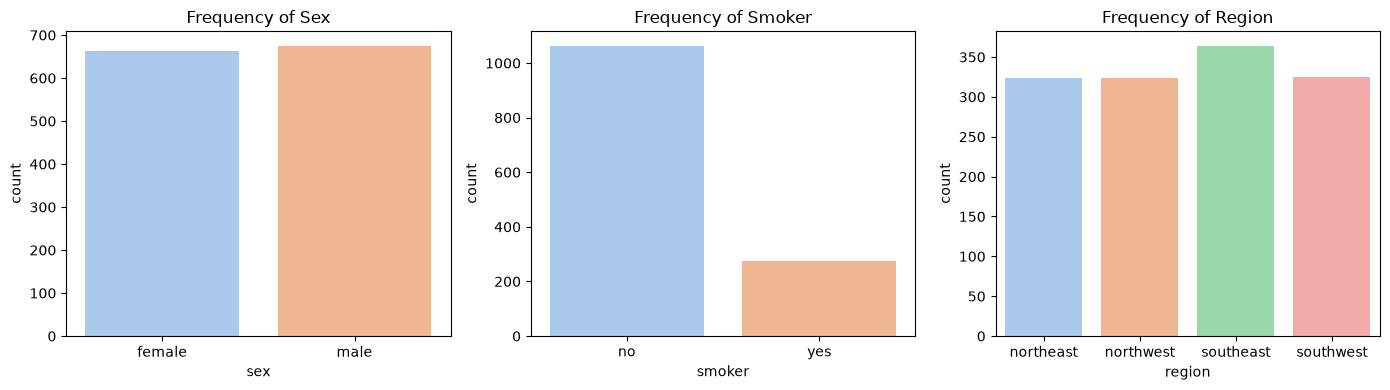

In [16]:
# Quick distribution overview for categories
plt.figure(figsize=(14, 4))
for i, col in enumerate(CAT_COLS):
    plt.subplot(1, len(CAT_COLS), i + 1)
    sns.countplot(data=df, x=col, palette="pastel")
    plt.title(f"Frequency of {col.capitalize()}")

plt.tight_layout()
plt.show()